In [107]:
# import packages

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder, OneHotEncoder
import keras
from keras.layers import Input, Dense
from keras.models import Model
import tensorflow as tf
from keras.callbacks import History
from keras.callbacks import CSVLogger
from scipy.stats import linregress
from sklearn.model_selection import train_test_split

## no time coordinate so include function

In [3]:
def help_adding_year(yr):
    """
    Update year string by adding one and return string.
    Args:
        yr (str): year
    """
    assert len(yr) == 4, 'year string is not correct length!'
    newyr = int(yr) + 1
    newyr = str(newyr)
    newyr = newyr.zfill(4)
    return newyr


def convert_mo_str(mo):
    """
    Convert integer month to two-digit month string.
    Args:
        mo (int): month
    """
    assert type(mo) is int, 'not an integer'
    return str(mo).zfill(2)


def help_updating_time(mo, yr):
    """
    Updating the month and year in cftime due to february start in cesm.
    Year and month (if december) are fixed.
    Args:
        mo (str): xarray filename
        yr (str): xarray filename
    """
    newmo = int(mo) + 1
    if newmo == 13:
        yr = help_adding_year(yr)
        newmo = 1
    assert newmo <= 12, 'month is greater than 12, there is an error!'
    newmo = convert_mo_str(newmo)
    return newmo, yr


def fixtime(ds):
    """
    Open file and add time coordinate.
    Args:
        ds (xarray dataset)
    """
    # start date range preprocessing
    mo0 = ds.encoding['source'].split('/')[-1].split('.')[-2][4:6]
    yr0 = ds.encoding['source'].split('/')[-1].split('.')[-2][:4]
    nm0, ny0 = help_updating_time(mo0, yr0)
    # end date range preprocessing
    yr1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-6:-2]
    mo1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-2:]
    nm1, ny1 = help_updating_time(mo1, yr1)
    # create datetime array in cftime
    newtime = xr.cftime_range(
        start=ny0+'-'+nm0+'-01',
        end=ny1+'-'+nm1+'-01',
        freq='MS',
        calendar='noleap'
    )
    ds = ds.assign_coords(time=newtime)
    return ds

## open_mfdataset() and fix time issue (start 01-01 not 02-01)

In [4]:
ds_ohc = xr.open_mfdataset(
    '/glade/campaign/cgd/cas/fasullo/E3SMLEv2/ocn/month_1/heat700/v2.FV1.piControl.heat700.*.nc',
    preprocess=fixtime,
    concat_dim='time',
    combine='nested'
)

ds_ssh = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_ssh.*.nc',
    preprocess=fixtime,
    concat_dim='time',
    combine='nested'
)

In [5]:
ds_ohc

<xarray.Dataset> Size: 5GB
Dimensions:    (time: 6000, lat: 180, nbnd: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 48kB 0001-02-01 00:00:00 ... 0501-01-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    heat700    (time, lat, lon) float32 2GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    time_bnds  (time, nbnd) object 96kB dask.array<chunksize=(6000, 2), meta=np.ndarray>
Attributes: (12/749)
    title:                                                        MPAS-Ocean ...
    source:                                                       MPAS Ocean
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         v2.LR.piCon...
    ...                                                           ...
    remap_script:                                                 ncremap
    remap_hostname:                                               nid00846
    remap_version:                                                5.0.1
    nco_openmp_thread_number:                                     2
    map_file:                                                     /global/u2/...
    input_file:                                                   ./ncremap_t...

In [6]:
ds_ssh

<xarray.Dataset> Size: 5GB
Dimensions:              (time: 6000, lat: 180, nbnd: 2, lon: 360)
Coordinates:
  * lat                  (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                  (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * time                 (time) object 48kB 0001-02-01 00:00:00 ... 0501-01-0...
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds             (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds             (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                   (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                 (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_ssh  (time, lat, lon) float32 2GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    time_bnds            (time, nbnd) object 96kB dask.array<chunksize=(6000, 2), meta=np.ndarray>
Attributes: (12/749)
    title:                                                        MPAS-Ocean ...
    source:                                                       MPAS Ocean
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         v2.LR.piCon...
    ...                                                           ...
    remap_script:                                                 ncremap
    remap_hostname:                                               nid00846
    remap_version:                                                5.0.1
    nco_openmp_thread_number:                                     2
    map_file:                                                     /global/u2/...
    input_file:                                                   ./ncremap_t...

In [7]:
ds_ohc = ds_ohc.assign_coords(
    time=ds_ohc['time'] - xr.coding.cftime_offsets.MonthBegin(1)
)
ds_ssh = ds_ssh.assign_coords(
    time=ds_ssh['time'] - xr.coding.cftime_offsets.MonthBegin(1)
)

In [8]:
ds_ohc

<xarray.Dataset> Size: 5GB
Dimensions:    (time: 6000, lat: 180, nbnd: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    heat700    (time, lat, lon) float32 2GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    time_bnds  (time, nbnd) object 96kB dask.array<chunksize=(6000, 2), meta=np.ndarray>
Attributes: (12/749)
    title:                                                        MPAS-Ocean ...
    source:                                                       MPAS Ocean
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         v2.LR.piCon...
    ...                                                           ...
    remap_script:                                                 ncremap
    remap_hostname:                                               nid00846
    remap_version:                                                5.0.1
    nco_openmp_thread_number:                                     2
    map_file:                                                     /global/u2/...
    input_file:                                                   ./ncremap_t...

In [9]:
ds_ssh

<xarray.Dataset> Size: 5GB
Dimensions:              (time: 6000, lat: 180, nbnd: 2, lon: 360)
Coordinates:
  * lat                  (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                  (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * time                 (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-0...
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds             (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds             (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                   (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                 (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_ssh  (time, lat, lon) float32 2GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    time_bnds            (time, nbnd) object 96kB dask.array<chunksize=(6000, 2), meta=np.ndarray>
Attributes: (12/749)
    title:                                                        MPAS-Ocean ...
    source:                                                       MPAS Ocean
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         v2.LR.piCon...
    ...                                                           ...
    remap_script:                                                 ncremap
    remap_hostname:                                               nid00846
    remap_version:                                                5.0.1
    nco_openmp_thread_number:                                     2
    map_file:                                                     /global/u2/...
    input_file:                                                   ./ncremap_t...

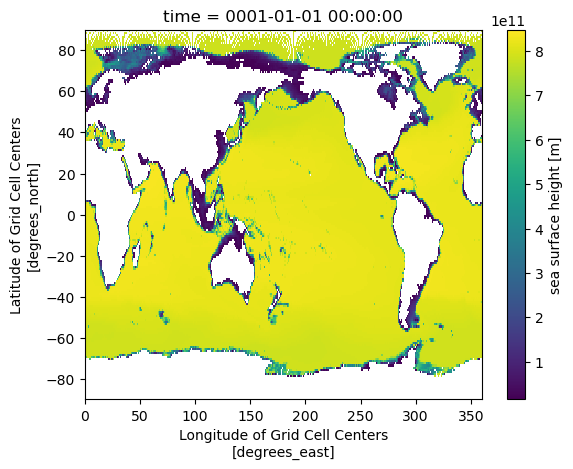

In [10]:
# checking our sanity
ds_ohc['heat700'].isel(time=0).where(
    ds_ohc['heat700'].isel(time=0) <= 1e35, np.nan).plot()

## Slice files to Tropical Pacific Region

In [11]:
print(
    ds_ohc['heat700'].shape, ds_ssh['timeMonthly_avg_ssh'].shape
)

(6000, 180, 360) (6000, 180, 360)


In [12]:
ds_ohc = ds_ohc['heat700']
ds_ssh = ds_ssh['timeMonthly_avg_ssh']

In [13]:
ds_ohc

<xarray.DataArray 'heat700' (time: 6000, lat: 180, lon: 360)> Size: 2GB
dask.array<concatenate, shape=(6000, 180, 360), dtype=float32, chunksize=(120, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
Attributes:
    units:          m
    long_name:      sea surface height
    cell_methods:   Time: mean
    cell_measures:  area: area

In [14]:
ds_ssh

<xarray.DataArray 'timeMonthly_avg_ssh' (time: 6000, lat: 180, lon: 360)> Size: 2GB
dask.array<concatenate, shape=(6000, 180, 360), dtype=float32, chunksize=(120, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
Attributes:
    units:          m
    long_name:      sea surface height
    cell_methods:   Time: mean
    cell_measures:  area: area

In [15]:
# new spatial bounds
ds_ohc_tp = ds_ohc.sel(lat=slice(-10, 10), lon=slice(130, 280))
ds_ssh_tp = ds_ssh.sel(lat=slice(-10, 10), lon=slice(130, 280))

In [16]:
print(ds_ohc_tp.shape, ds_ssh_tp.shape)

(6000, 20, 150) (6000, 20, 150)


## Look for NaN values and use SSH to mask, then extraneous data points in OHC to mask

In [17]:
# Check if there are any NaN values in the SSH dataset
has_nan = ds_ssh_tp.isnull().any()

print(f"SSH dataset contains NaN values: {has_nan.values}")

# Count the number of NaN values in the SSH dataset
nan_count = ds_ssh_tp.isnull().sum()
print(f"Number of NaN values in SSH dataset: {nan_count.values}")

SSH dataset contains NaN values: True
Number of NaN values in SSH dataset: 192000


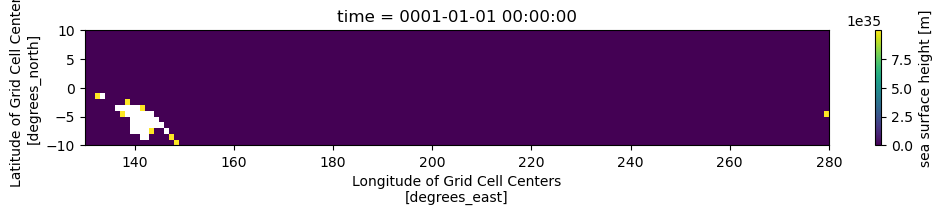

In [18]:
# Mask land pixels in OHC data using the NaN values in SSH data
ohc_ocean_only = ds_ohc_tp.where(~ds_ssh_tp.isnull(), np.nan)

# Plot to confirm that land areas are masked
ohc_ocean_only[0].plot.pcolormesh(figsize=(12, 1.5))

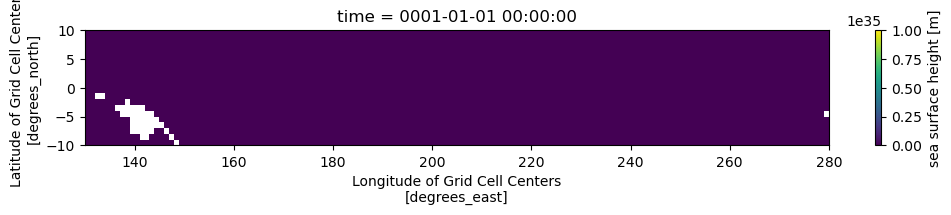

In [19]:
ohc_ocean_only[0].where(ohc_ocean_only[0] <= 1e35, np.nan).plot.pcolormesh(
    figsize=(12, 1.5), vmin=0, vmax=1e35)

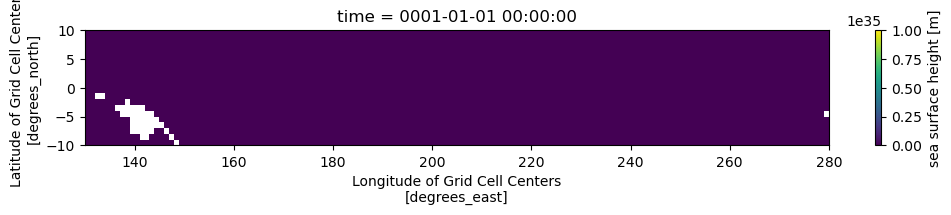

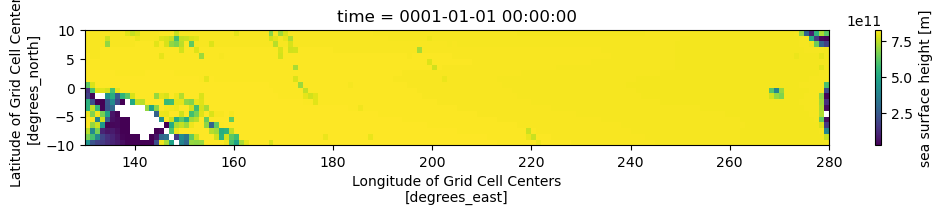

In [20]:
# Mask values that are either greater than 1e35 or equal to -9.4371840e+06 in the OHC data
# Apply the first condition for values less than or equal to 1e35
valid_ohc = ohc_ocean_only.where(ohc_ocean_only[0] <= 1e35, np.nan)

valid_ohc[0].plot.pcolormesh(figsize=(12, 1.5), vmin=0, vmax=1e35); plt.show()
valid_ohc[0].plot.pcolormesh(figsize=(12, 1.5)); plt.show()

In [21]:
print(ds_ssh_tp.shape, ohc_ocean_only.shape, valid_ohc.shape)

(6000, 20, 150) (6000, 20, 150) (6000, 20, 150)


### Anoms

In [22]:
tmpclim = valid_ohc.groupby('time.month').mean(dim='time', keep_attrs=True)
tmpanom = valid_ohc.groupby('time.month') - tmpclim

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/xarray/core/indexing.py:1621: PerformanceWarning: Slicing with an out-of-order index is generating 500 times more chunks
  return self.array[key]


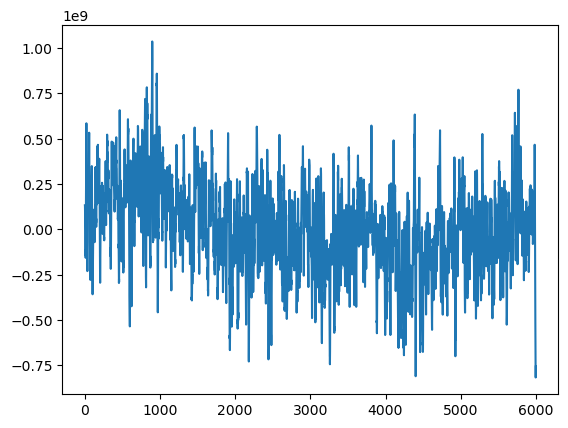

In [23]:
plt.plot(range(0,6000), tmpanom.mean(dim=['lat','lon']))
plt.show()

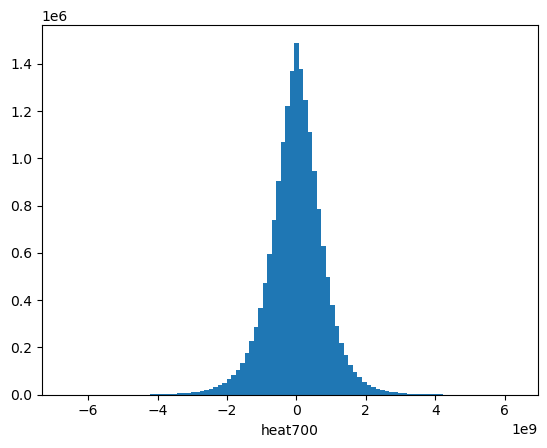

In [24]:
tmpanom.stack(newdim=['time', 'lon', 'lat']).plot.hist(bins=100)
plt.show()

In [25]:
print(tmpanom.min().values, tmpanom.max().values)

-6685065000.0 6303711000.0


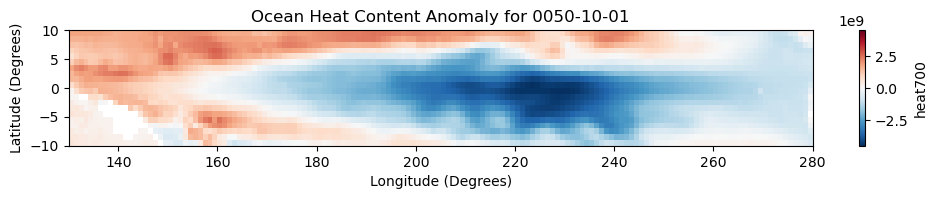

In [26]:
tmpanom.isel(time=597).plot.pcolormesh(figsize=(12, 1.5))
plt.title('Ocean Heat Content Anomaly for 0050-10-01')
plt.xlabel('Longitude (Degrees)')
plt.ylabel('Latitude (Degrees)')

#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/agufigs/ohcinput.pdf', bbox_inches='tight')
plt.show()

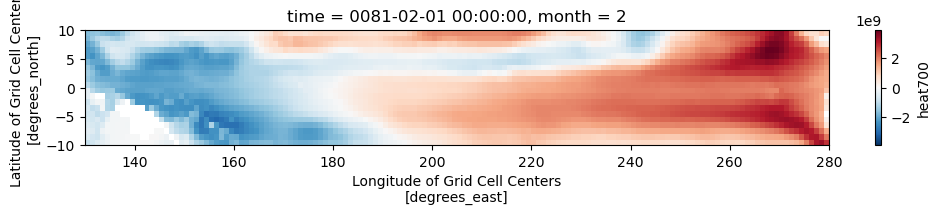

In [27]:
tmpanom.isel(time=961).plot.pcolormesh(figsize=(12, 1.5))

In [28]:
tmpanom

<xarray.DataArray 'heat700' (time: 6000, lat: 20, lon: 150)> Size: 72MB
dask.array<sub, shape=(6000, 20, 150), dtype=float32, chunksize=(1, 20, 150), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 160B -9.5 -8.5 -7.5 -6.5 -5.5 ... 5.5 6.5 7.5 8.5 9.5
  * lon      (lon) float64 1kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

# How to do grid reconstruction [from Maria]

In [29]:
def create_index_mask(da):
    """
    Create index mask for reconstruction of predictions.
    Args:
        da (xarray data array): 2d input variable samples
    Returns:
        y_, x_ (numpy arrays): x and y indices for reconstruction
    """
    # just one sample needed; time=0
    da = da.isel(time=0)
    
    # original 2d grid shape
    orig_2d_shape = da.shape
    
    # location of the valid values (not nan) in 1d vector
    orig_indx = np.where(~np.isnan(da.stack(newdim=['lat', 'lon']).values))[0]
    
    # Indices of non-nan values in original 2d grid
    y_, x_ = np.unravel_index(orig_indx, orig_2d_shape)
    
    # return the respective indices for (20, 150)
    return y_, x_

def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d.values
    
    # return predictions on original 2d grid
    return pred_grid

In [30]:
# produce the indices to be used
y_vals, x_vals = create_index_mask(tmpanom)

# save the numpy arrays of the y, x indices
np.save('ohc_yindx.npy', y_vals)
np.save('ohc_xindx.npy', x_vals)

In [31]:
# indices can be loaded anytime and used for reconstruction
yindx = np.load('ohc_yindx.npy')
xindx = np.load('ohc_xindx.npy')

### fake predictions here just using actual data
# flattened grid shape
heat_newdim = tmpanom.stack(newdim=['lat', 'lon'])
# flattened grid shape after dropping nans
heat_processed = heat_newdim.dropna('newdim', how='any')

# now reconstruct fake predictions
predictions_2d = reconstruct_grid(heat_processed, yindx, xindx)

# can close files like this
del yindx
del xindx

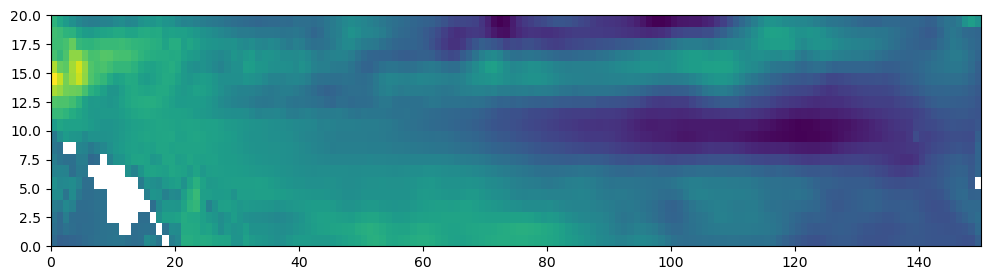

In [32]:
# quick viz of reconstruction
plt.figure(figsize=(12,3))
plt.pcolormesh(predictions_2d[0,:,:])
plt.show()

## Split into Train/Test

In [33]:
heat_train, heat_test = train_test_split(
    heat_processed, test_size=0.2, random_state=0, shuffle=True
)

In [34]:
print(heat_train.shape, heat_test.shape)

(4800, 2960) (1200, 2960)


In [35]:
heat_train

<xarray.DataArray 'heat700' (time: 4800, newdim: 2960)> Size: 57MB
dask.array<getitem, shape=(4800, 2960), dtype=float32, chunksize=(1, 2960), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [36]:
heat_test

<xarray.DataArray 'heat700' (time: 1200, newdim: 2960)> Size: 14MB
dask.array<getitem, shape=(1200, 2960), dtype=float32, chunksize=(1, 2960), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

## Use Robust Scaler

In [80]:
from sklearn.preprocessing import RobustScaler

heat_train_tmp = heat_train.copy()
heat_train_tmp = heat_train_tmp.values

scaler_tmp = RobustScaler()
scaler_tmp_ohc = scaler_tmp.fit(heat_train_tmp.reshape(4800 * 2960, 1))

In [83]:
scaler = RobustScaler()

scaler_ohc = scaler.fit(heat_train)

In [90]:
scaler_ohc.center_ = np.repeat(scaler_tmp_ohc.center_, 2960)

In [93]:
scaler_ohc.scale_ = np.repeat(scaler_tmp_ohc.scale_, 2960)

In [95]:
scaled_input_ohc_train = scaler_ohc.transform(heat_train)

scaled_input_ohc_test = scaler_ohc.transform(heat_test)

print(scaled_input_ohc_train.shape, scaled_input_ohc_test.shape)

(4800, 2960) (1200, 2960)


In [123]:
import joblib

# Save the scaler to a file
joblib.dump(scaler_ohc, 'scaler_ohc_700_0228.pkl')

print("Scaler saved successfully!")

Scaler saved successfully!


In [96]:
scaled_input_ohc_train[:-10]

array([[-0.42270616, -0.27264473, -0.24234334, ..., -0.05016352,
        -0.04759775,  0.07686018],
       [ 0.12123717, -0.06499802, -0.13002765, ...,  0.13092205,
         0.25949967,  0.2127376 ],
       [ 0.00483792, -0.03959327, -0.0446164 , ...,  0.41673443,
         0.6304161 ,  0.5665971 ],
       ...,
       [-0.21451738, -0.10156927, -0.07002114, ..., -0.19644858,
        -0.37717277, -0.491729  ],
       [ 0.02131667,  0.15836857,  0.19616851, ..., -0.4157316 ,
        -0.6355567 , -0.6220412 ],
       [-0.2618215 , -0.3238698 , -0.32372525, ...,  0.12279109,
         0.18389979,  0.1512314 ]], dtype=float32)

In [97]:
scaled_input_ohc_test[:10]

array([[ 0.27984515,  0.1208758 ,  0.0409394 , ..., -0.13736358,
        -0.19034132, -0.16533409],
       [-0.0235301 , -0.05337977, -0.12280012, ...,  0.18595964,
         0.30069655,  0.34529036],
       [-1.0816755 , -0.8742637 , -0.6106579 , ...,  0.1987885 ,
         0.382223  ,  0.3536743 ],
       ...,
       [ 0.30109406,  0.37177923,  0.35432476, ...,  0.03533807,
         0.04346903,  0.07490876],
       [-0.43249947, -0.34618476, -0.3070658 , ...,  0.3706951 ,
         0.50530773,  0.42089024],
       [ 0.6474369 ,  0.49840543,  0.4756568 , ...,  0.26033083,
         0.30987552,  0.17284168]], dtype=float32)

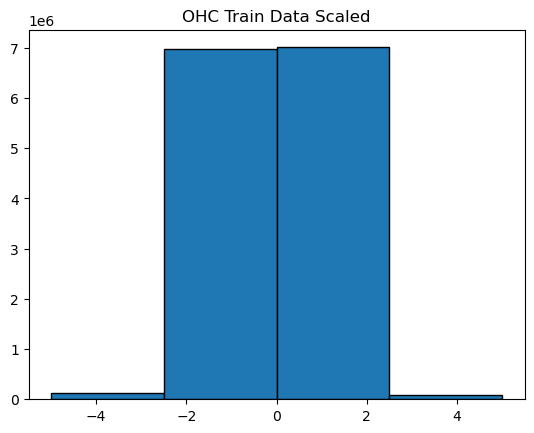

In [98]:
plt.hist(scaled_input_ohc_train.flatten(), 
         bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OHC Train Data Scaled')
plt.show()

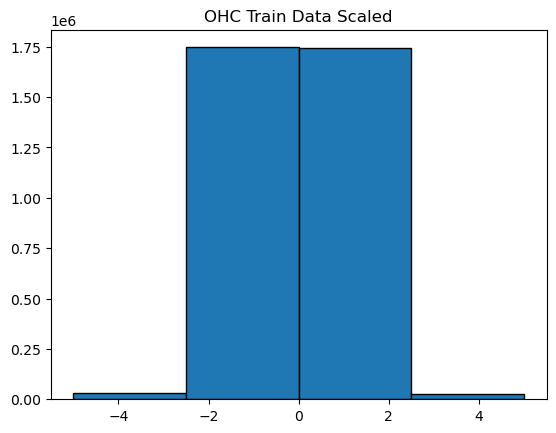

In [99]:
plt.hist(scaled_input_ohc_test.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OHC Train Data Scaled')
plt.show()

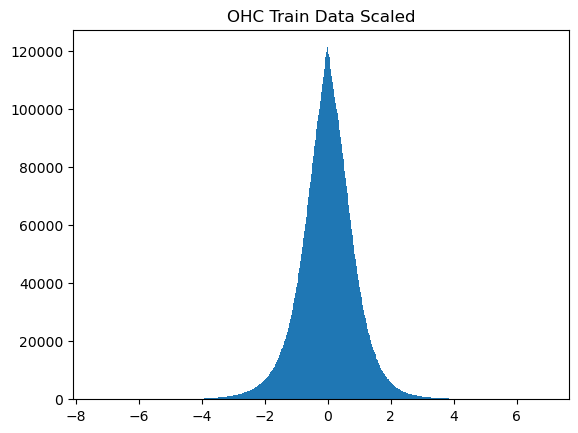

In [100]:
plt.hist(
    scaled_input_ohc_train.flatten(),
    bins=1000,
)
plt.title('OHC Train Data Scaled')
plt.show()

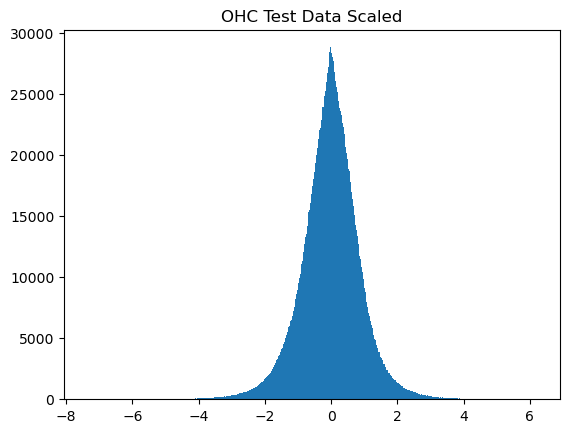

In [101]:
plt.hist(
    scaled_input_ohc_test.flatten(),
    bins=1000,
)
plt.title('OHC Test Data Scaled')
plt.show()

## Save out files

In [124]:
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt

## RETAIN TIME COMPONENT FOR SORTING LATER ON

In [125]:
scaled_input_ohc_train

array([[-0.42270616, -0.27264473, -0.24234334, ..., -0.05016352,
        -0.04759775,  0.07686018],
       [ 0.12123717, -0.06499802, -0.13002765, ...,  0.13092205,
         0.25949967,  0.2127376 ],
       [ 0.00483792, -0.03959327, -0.0446164 , ...,  0.41673443,
         0.6304161 ,  0.5665971 ],
       ...,
       [-0.08966193, -0.01263461,  0.04462544, ..., -0.23713952,
        -0.29962146, -0.18520978],
       [-0.51023144, -0.20279072, -0.12083063, ...,  0.11299779,
         0.16922791,  0.13041613],
       [-0.5901317 , -0.37921456, -0.23081544, ..., -0.05471686,
        -0.06385968, -0.04535722]], dtype=float32)

In [126]:
scaled_input_ohc_test

array([[ 0.27984515,  0.1208758 ,  0.0409394 , ..., -0.13736358,
        -0.19034132, -0.16533409],
       [-0.0235301 , -0.05337977, -0.12280012, ...,  0.18595964,
         0.30069655,  0.34529036],
       [-1.0816755 , -0.8742637 , -0.6106579 , ...,  0.1987885 ,
         0.382223  ,  0.3536743 ],
       ...,
       [ 0.03298912,  0.10255402,  0.14069727, ...,  0.14100444,
         0.2600056 ,  0.14732853],
       [ 0.35562572,  0.37593505,  0.38173515, ...,  0.13561994,
         0.16496368,  0.16337363],
       [-0.9116842 , -0.61154324, -0.50289553, ...,  0.32816115,
         0.4723502 ,  0.46367717]], dtype=float32)

In [127]:
import xarray as xr

# Get original coordinates for each dimension
coords = heat_train.coords  # Retains 'time', 'lat', 'lon', etc.
dims = heat_train.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
heat_train_coords = xr.DataArray(scaled_input_ohc_train, dims=dims, coords=coords)

In [128]:
heat_train_coords

<xarray.DataArray (time: 4800, newdim: 2960)> Size: 57MB
array([[-0.42270616, -0.27264473, -0.24234334, ..., -0.05016352,
        -0.04759775,  0.07686018],
       [ 0.12123717, -0.06499802, -0.13002765, ...,  0.13092205,
         0.25949967,  0.2127376 ],
       [ 0.00483792, -0.03959327, -0.0446164 , ...,  0.41673443,
         0.6304161 ,  0.5665971 ],
       ...,
       [-0.08966193, -0.01263461,  0.04462544, ..., -0.23713952,
        -0.29962146, -0.18520978],
       [-0.51023144, -0.20279072, -0.12083063, ...,  0.11299779,
         0.16922791,  0.13041613],
       [-0.5901317 , -0.37921456, -0.23081544, ..., -0.05471686,
        -0.06385968, -0.04535722]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [129]:
# Get original coordinates for each dimension
coords = heat_test.coords  # Retains 'time', 'lat', 'lon', etc.
dims = heat_test.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
heat_test_coords = xr.DataArray(scaled_input_ohc_test, dims=dims, coords=coords)

In [130]:
heat_test_coords

<xarray.DataArray (time: 1200, newdim: 2960)> Size: 14MB
array([[ 0.27984515,  0.1208758 ,  0.0409394 , ..., -0.13736358,
        -0.19034132, -0.16533409],
       [-0.0235301 , -0.05337977, -0.12280012, ...,  0.18595964,
         0.30069655,  0.34529036],
       [-1.0816755 , -0.8742637 , -0.6106579 , ...,  0.1987885 ,
         0.382223  ,  0.3536743 ],
       ...,
       [ 0.03298912,  0.10255402,  0.14069727, ...,  0.14100444,
         0.2600056 ,  0.14732853],
       [ 0.35562572,  0.37593505,  0.38173515, ...,  0.13561994,
         0.16496368,  0.16337363],
       [-0.9116842 , -0.61154324, -0.50289553, ...,  0.32816115,
         0.4723502 ,  0.46367717]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [131]:
print(heat_train_coords.shape, heat_test_coords.shape)

(4800, 2960) (1200, 2960)


In [132]:
# Convert MultiIndex levels in `newdim` into separate coordinates
ohc_train_reset_index = heat_train_coords.reset_index('newdim')

In [133]:
ohc_train_reset_index

<xarray.DataArray (time: 4800, newdim: 2960)> Size: 57MB
array([[-0.42270616, -0.27264473, -0.24234334, ..., -0.05016352,
        -0.04759775,  0.07686018],
       [ 0.12123717, -0.06499802, -0.13002765, ...,  0.13092205,
         0.25949967,  0.2127376 ],
       [ 0.00483792, -0.03959327, -0.0446164 , ...,  0.41673443,
         0.6304161 ,  0.5665971 ],
       ...,
       [-0.08966193, -0.01263461,  0.04462544, ..., -0.23713952,
        -0.29962146, -0.18520978],
       [-0.51023144, -0.20279072, -0.12083063, ...,  0.11299779,
         0.16922791,  0.13041613],
       [-0.5901317 , -0.37921456, -0.23081544, ..., -0.05471686,
        -0.06385968, -0.04535722]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [134]:
# Convert MultiIndex levels in `newdim` into separate coordinates
ohc_test_reset_index = heat_test_coords.reset_index('newdim')

In [135]:
ohc_test_reset_index

<xarray.DataArray (time: 1200, newdim: 2960)> Size: 14MB
array([[ 0.27984515,  0.1208758 ,  0.0409394 , ..., -0.13736358,
        -0.19034132, -0.16533409],
       [-0.0235301 , -0.05337977, -0.12280012, ...,  0.18595964,
         0.30069655,  0.34529036],
       [-1.0816755 , -0.8742637 , -0.6106579 , ...,  0.1987885 ,
         0.382223  ,  0.3536743 ],
       ...,
       [ 0.03298912,  0.10255402,  0.14069727, ...,  0.14100444,
         0.2600056 ,  0.14732853],
       [ 0.35562572,  0.37593505,  0.38173515, ...,  0.13561994,
         0.16496368,  0.16337363],
       [-0.9116842 , -0.61154324, -0.50289553, ...,  0.32816115,
         0.4723502 ,  0.46367717]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [136]:
# Save the xarray DataArray to a NetCDF file
heat_train = ohc_train_reset_index.to_netcdf('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_train_robustscaler.nc')
heat_test = ohc_test_reset_index.to_netcdf('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_test_robustscaler.nc')

In [137]:
# ohc train and test
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_train_robustscaler.csv',
        scaled_input_ohc_train, delimiter=',')
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/ohc700_test_robustscaler.csv',
        scaled_input_ohc_test, delimiter=',')

## OHC only autoencoder test

In [2]:
# import packages

from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt

# csv to numpy array
# ohc train and test
scaled_input_ohc_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/ohc_train_1109.csv',
                                    delimiter=',')
scaled_input_ohc_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/ohc_test_1109.csv',
                                   delimiter=',')

In [65]:
scaled_input_ohc_train[:10]

array([[-0.42585447, -0.40537062, -0.4414991 , ..., -0.04153242,
        -0.07204325,  0.15508126],
       [ 0.06552944, -0.09882185, -0.22554393, ..., -0.4725558 ,
        -0.23919801, -0.28430754],
       [-0.00657527, -0.03993694, -0.06131932, ...,  0.67436004,
         0.9339491 ,  0.99388796],
       ...,
       [-0.07565288,  0.07036944,  0.09547053, ..., -1.3035557 ,
        -1.3633251 , -1.3341256 ],
       [ 0.27484646,  0.3194346 ,  0.3541929 , ..., -0.57085115,
        -0.7068709 , -0.8485569 ],
       [ 0.20740649, -0.00761574, -0.02056716, ...,  0.25095192,
         0.14404145,  0.223187  ]], dtype=float32)

In [66]:
scaled_input_ohc_test[:10]

array([[ 0.40387073,  0.23541777,  0.10318322, ..., -0.3136899 ,
        -0.33219194, -0.37365997],
       [-0.04955028, -0.06790194, -0.2116472 , ...,  0.73282176,
         0.7735526 ,  0.86572886],
       [-1.5019664 , -1.4529004 , -1.1496764 , ...,  0.14222951,
         0.2601036 ,  0.30060634],
       ...,
       [ 0.5230197 ,  0.6743281 ,  0.70574546, ...,  0.32481986,
         0.26217616,  0.30574825],
       [-0.5079834 , -0.5412659 , -0.5659443 , ...,  1.0644368 ,
         1.1320118 ,  1.1077856 ],
       [ 0.7956578 ,  0.8509828 ,  0.9390368 , ...,  0.26173043,
         0.30182475,  0.2555906 ]], dtype=float32)

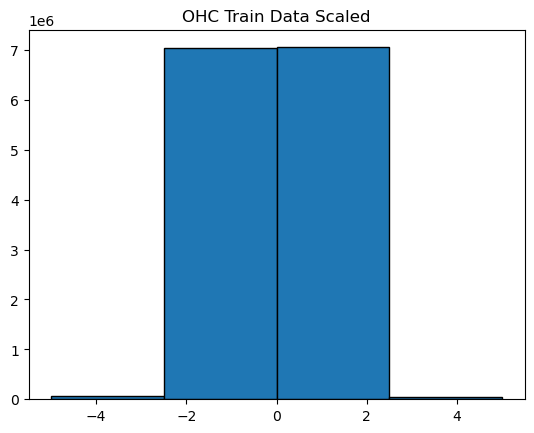

In [67]:
plt.hist(scaled_input_ohc_train.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OHC Train Data Scaled')
plt.show()

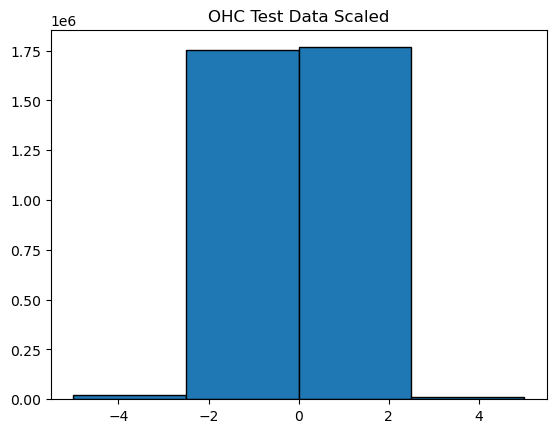

In [68]:
plt.hist(scaled_input_ohc_test.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OHC Test Data Scaled')
plt.show()

## Build Autoencoder

In [110]:
keras.utils.set_random_seed(1)

In [112]:
input_shape_ohc = scaled_input_ohc_train.shape[1]
print(input_shape_ohc)

2960


In [113]:
type(np.int64(input_shape_ohc),)

numpy.int64

In [114]:
np.int64(input_shape_ohc).dtype

dtype('int64')

In [115]:
# ohc1 input
input_ohc_1 = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc_1')
print(input_ohc_1.shape)

# add 2 dense layers
encoded_ohc_1_layer1 = Dense(50, activation='tanh')(input_ohc_1)
encoded_ohc_1_layer2 = Dense(25, activation='tanh')(encoded_ohc_1_layer1)
encoded_ohc_1_layer3 = Dense(10, activation='tanh')(encoded_ohc_1_layer2)

# ssh input
input_ohc_2 = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc_2')
print(input_ohc_2.shape)

# add 2 dense layers (again)
encoded_ohc_2_layer1 = Dense(50, activation='tanh')(input_ohc_2)
encoded_ohc_2_layer2 = Dense(25, activation='tanh')(encoded_ohc_2_layer1)
encoded_ohc_2_layer3 = Dense(10, activation='tanh')(encoded_ohc_2_layer2)

# zonal stress input 
# ssh input
input_ohc_3 = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc_3')
print(input_ohc_3.shape)

# add 2 dense layers (again)
encoded_ohc_3_layer1 = Dense(50, activation='tanh')(input_ohc_3)
encoded_ohc_3_layer2 = Dense(25, activation='tanh')(encoded_ohc_3_layer1)
encoded_ohc_3_layer3 = Dense(10, activation='tanh')(encoded_ohc_3_layer2)

(None, 2960)


2025-02-28 09:34:42.125033: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


(None, 2960)
(None, 2960)


In [116]:
# add concatenation layer
# merge 3 input fields
bottleneck = keras.layers.concatenate(
    [encoded_ohc_1_layer3, encoded_ohc_2_layer3, encoded_ohc_3_layer3])
bottleneck1 = Dense(1, activation='tanh')(bottleneck)
print(bottleneck1)

# build decoder for each variable from the bottleneck
# sst
decoded_ohc_1_layer1 = Dense(10, activation='tanh')(bottleneck1)
decoded_ohc_1_layer2 = Dense(25, activation='tanh')(decoded_ohc_1_layer1)
decoded_ohc_1_layer3 = Dense(50, activation='tanh')(decoded_ohc_1_layer2)
output_ohc_1 = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc_1')(decoded_ohc_1_layer3)
print(output_ohc_1.shape)

# build decoder for each variable from the bottleneck
# ssh
decoded_ohc_2_layer1 = Dense(10, activation='tanh')(bottleneck1)
decoded_ohc_2_layer2 = Dense(25, activation='tanh')(decoded_ohc_2_layer1)
decoded_ohc_2_layer3 = Dense(50, activation='tanh')(decoded_ohc_2_layer2)
output_ohc_2 = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc_2')(decoded_ohc_2_layer3)
print(output_ohc_2.shape)

# build decoder for each variable from the bottleneck
# zonal stress
decoded_ohc_3_layer1 = Dense(10, activation='tanh')(bottleneck1)
decoded_ohc_3_layer2 = Dense(25, activation='tanh')(decoded_ohc_3_layer1)
decoded_ohc_3_layer3 = Dense(50, activation='tanh')(decoded_ohc_3_layer2)
output_ohc_3 = Dense(
    np.int64(input_shape_ohc), activation='linear', name='output_ohc_3')(decoded_ohc_3_layer3)
print(output_ohc_3.shape)

KerasTensor(type_spec=TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), name='dense_9/Tanh:0', description="created by layer 'dense_9'")
(None, 2960)
(None, 2960)
(None, 2960)


In [117]:
# only using lists
# maps inputs to outputs
enso_model = Model(inputs=[input_ohc_1, input_ohc_2, input_ohc_3],
                   outputs=[output_ohc_1, output_ohc_2, output_ohc_3])

# compile the model using lists
opt = keras.optimizers.Adam(learning_rate=0.00075)
enso_model.compile(optimizer=opt,
                   loss='mean_squared_error',
                   metrics=['accuracy']
                  )

In [118]:
enso_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ohc_1 (InputLayer)    [(None, 2960)]               0         []                            
                                                                                                  
 input_ohc_2 (InputLayer)    [(None, 2960)]               0         []                            
                                                                                                  
 input_ohc_3 (InputLayer)    [(None, 2960)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 50)                   148050    ['input_ohc_1[0][0]']         
                                                                                              

In [119]:
# train the model!
enso_model_history = enso_model.fit(x=[scaled_input_ohc_train,
                                       scaled_input_ohc_train,
                                       scaled_input_ohc_train],
                                    y=[scaled_input_ohc_train,
                                       scaled_input_ohc_train,
                                       scaled_input_ohc_train],
                                    epochs=100,
                                    batch_size=256,
                                    validation_split=0.3
                                   )

Epoch 1/100
14/14 [==============================] - 4s 81ms/step - loss: 2.3085 - output_ohc_1_loss: 0.7677 - output_ohc_2_loss: 0.7701 - output_ohc_3_loss: 0.7708 - output_ohc_1_accuracy: 0.0000e+00 - output_ohc_2_accuracy: 0.0065 - output_ohc_3_accuracy: 2.9762e-04 - val_loss: 2.2133 - val_output_ohc_1_loss: 0.7304 - val_output_ohc_2_loss: 0.7409 - val_output_ohc_3_loss: 0.7419 - val_output_ohc_1_accuracy: 0.0000e+00 - val_output_ohc_2_accuracy: 6.9444e-04 - val_output_ohc_3_accuracy: 0.0000e+00
Epoch 2/100
14/14 [==============================] - 1s 44ms/step - loss: 2.0848 - output_ohc_1_loss: 0.6844 - output_ohc_2_loss: 0.6998 - output_ohc_3_loss: 0.7005 - output_ohc_1_accuracy: 0.0000e+00 - output_ohc_2_accuracy: 0.0018 - output_ohc_3_accuracy: 0.0015 - val_loss: 1.9252 - val_output_ohc_1_loss: 0.6293 - val_output_ohc_2_loss: 0.6480 - val_output_ohc_3_loss: 0.6478 - val_output_ohc_1_accuracy: 0.0000e+00 - val_output_ohc_2_accuracy: 0.0000e+00 - val_output_ohc_3_accuracy: 0.0021


In [120]:
from keras.callbacks import History
tf.keras.callbacks.History()

# print dictionary keys
print(enso_model_history.history.keys())

# print model parameters
print(enso_model_history.params)

dict_keys(['loss', 'output_ohc_1_loss', 'output_ohc_2_loss', 'output_ohc_3_loss', 'output_ohc_1_accuracy', 'output_ohc_2_accuracy', 'output_ohc_3_accuracy', 'val_loss', 'val_output_ohc_1_loss', 'val_output_ohc_2_loss', 'val_output_ohc_3_loss', 'val_output_ohc_1_accuracy', 'val_output_ohc_2_accuracy', 'val_output_ohc_3_accuracy'])
{'verbose': 1, 'epochs': 100, 'steps': 14}


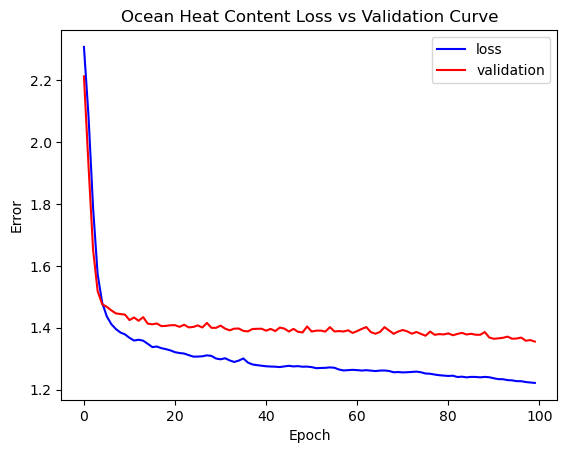

In [122]:
plt.plot(enso_model_history.history['loss'], label='loss', color='blue')
plt.plot(enso_model_history.history['val_loss'], label='validation', color='red')
plt.legend()
plt.title('Ocean Heat Content Loss vs Validation Curve')
plt.xlabel('Epoch')
plt.ylabel('Error')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/figures/ohconly_0825.png', dpi=350, bbox_inches='tight')
plt.show()

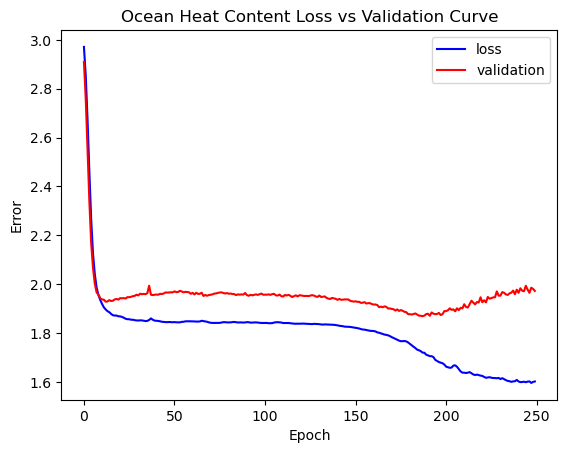

In [88]:
plt.plot(enso_model_history.history['loss'], label='loss', color='blue')
plt.plot(enso_model_history.history['val_loss'], label='validation', color='red')
plt.legend()
plt.title('Ocean Heat Content Loss vs Validation Curve')
plt.xlabel('Epoch')
plt.ylabel('Error')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/figures/ohconly_0825.png', dpi=350, bbox_inches='tight')
plt.show()

In [91]:
get_bottleneck = keras.backend.function([enso_model.layers[0].input,
                                      enso_model.layers[1].input,
                                      enso_model.layers[2].input],
                                     [enso_model.layers[10].output])

In [92]:
bottleneck_output = get_bottleneck([scaled_input_ohc_train,
                                    scaled_input_ohc_train,
                                    scaled_input_ohc_train])

In [93]:
bottleneck_output

[array([[-0.27004173],
        [-0.24295774],
        [ 0.05483012],
        ...,
        [-0.7084137 ],
        [-0.7707843 ],
        [-0.7205633 ]], dtype=float32)]

In [44]:
#bottleneck_scaled_back = scaler_ohc.inverse_transform(bottleneck_output[0])

In [94]:
bottleneck_output[0].shape

(4800, 1)

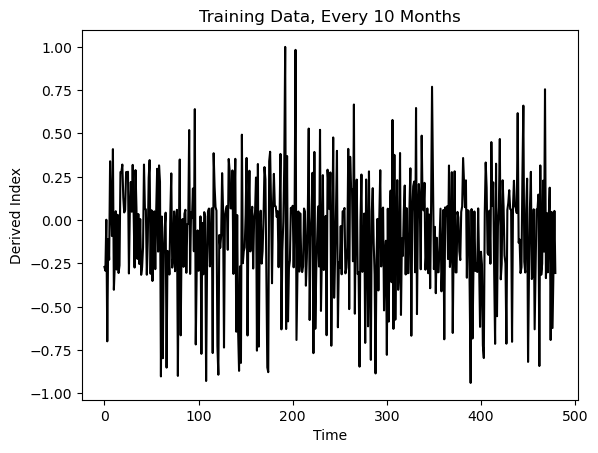

In [95]:
plt.plot(bottleneck_output[0][::10], color='black')
plt.title('Training Data, Every 10 Months')
plt.xlabel('Time')
plt.ylabel('Derived Index')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/bottlenecktrain_sstonly_0810.png', dpi=350)
plt.show()

In [98]:
bottleneck_train = bottleneck_output[0]
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/csv_10s10n/ohctraining_bottleneck_0825.csv', bottleneck_train, delimiter=',')

In [99]:
bottleneck_output_test = get_bottleneck([scaled_input_ohc_test,
                                         scaled_input_ohc_test,
                                         scaled_input_ohc_test])

In [100]:
bottleneck_output_test[0].shape

(1200, 1)

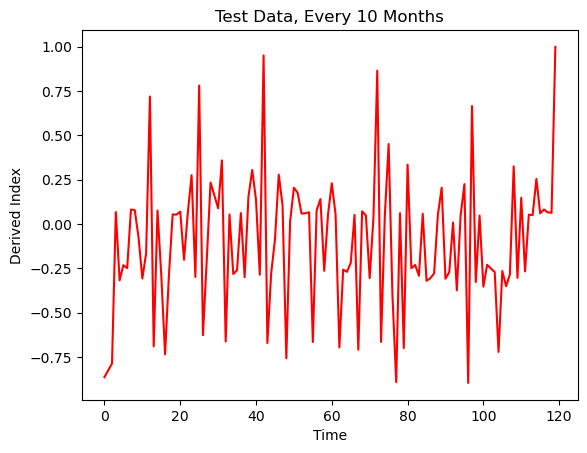

In [101]:
plt.plot(bottleneck_output_test[0][::10], color='red')
plt.title('Test Data, Every 10 Months')
plt.xlabel('Time')
plt.ylabel('Derived Index')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/bottlenecktest_sstonly_0810.png', dpi=350)
plt.show()

In [102]:
bottleneck_test = bottleneck_output_test[0]
savetxt('/glade/u/home/ewisinski/e3sm_autoencoder/csv_10s10n/ohctesting_bottleneck_0825.csv', bottleneck_test, delimiter=',')

In [103]:
training = pd.read_csv('/glade/u/home/ewisinski/e3sm_autoencoder/csv_10s10n/ohctraining_bottleneck_0825.csv',
                       engine='python', header=None)
test = pd.read_csv('/glade/u/home/ewisinski/e3sm_autoencoder/csv_10s10n/ohctesting_bottleneck_0825.csv',
                       engine='python', header=None)

In [104]:
training = training.values
test = test.values

In [105]:
training

array([[-0.27004173],
       [-0.24295774],
       [ 0.05483012],
       ...,
       [-0.70841372],
       [-0.77078432],
       [-0.72056329]])

In [106]:
test

array([[-0.86417967],
       [-0.89188361],
       [-0.83558375],
       ...,
       [-0.3357622 ],
       [-0.33946177],
       [-0.61993551]])

In [107]:
ensomodel_train = training.astype('float32')
ensomodel_test = test.astype('float32')

In [108]:
print(ensomodel_train.shape, ensomodel_test.shape)

(4800, 1) (1200, 1)


In [109]:
import pandas as pd

# Function to create a custom date string representation
def generate_custom_dates(start_year, start_month, periods):
    dates = []
    year, month = start_year, start_month
    for _ in range(periods):
        dates.append(f'{year:04d}-{month:02d}-01')
        month += 1
        if month > 12:
            month = 1
            year += 1
    return dates

# Create string representations of the train dates
ensomodel_train_index = pd.DataFrame(ensomodel_train)
train_dates = generate_custom_dates(start_year=1, start_month=2, periods=len(ensomodel_train_index))
ensomodel_train_index['date'] = train_dates
date_train = ensomodel_train_index['date']

# Create string representations of the test dates
ensomodel_test_index = pd.DataFrame(ensomodel_test)
test_dates = generate_custom_dates(start_year=401, start_month=2, periods=len(ensomodel_test_index))
ensomodel_test_index['date'] = test_dates
date_test = ensomodel_test_index['date']

In [110]:
ensomodel_train_index

,0,date
0,-0.270042,0001-02-01
1,-0.242958,0001-03-01
2,0.054830,0001-04-01
3,0.053879,0001-05-01
4,0.053214,0001-06-01
...,...,...
4795,-0.705074,0400-09-01
4796,-0.716981,0400-10-01
4797,-0.708414,0400-11-01
4798,-0.770784,0400-12-01


In [111]:
ensomodel_test_index

,0,date
0,-0.864180,0401-02-01
1,-0.891884,0401-03-01
2,-0.835584,0401-04-01
3,-0.241061,0401-05-01
4,-0.256108,0401-06-01
...,...,...
1195,-0.339626,0500-09-01
1196,-0.258973,0500-10-01
1197,-0.335762,0500-11-01
1198,-0.339462,0500-12-01


In [112]:
date_train

0       0001-02-01
1       0001-03-01
2       0001-04-01
3       0001-05-01
4       0001-06-01
           ...    
4795    0400-09-01
4796    0400-10-01
4797    0400-11-01
4798    0400-12-01
4799    0401-01-01
Name: date, Length: 4800, dtype: object

In [113]:
date_test

0       0401-02-01
1       0401-03-01
2       0401-04-01
3       0401-05-01
4       0401-06-01
           ...    
1195    0500-09-01
1196    0500-10-01
1197    0500-11-01
1198    0500-12-01
1199    0501-01-01
Name: date, Length: 1200, dtype: object

In [114]:
combined_dataset = pd.concat([ensomodel_train_index, ensomodel_test_index])

In [115]:
combined_dataset

,0,date
0,-0.270042,0001-02-01
1,-0.242958,0001-03-01
2,0.054830,0001-04-01
3,0.053879,0001-05-01
4,0.053214,0001-06-01
...,...,...
1195,-0.339626,0500-09-01
1196,-0.258973,0500-10-01
1197,-0.335762,0500-11-01
1198,-0.339462,0500-12-01


In [116]:
combined_dataset.reset_index(drop=True, inplace=True)

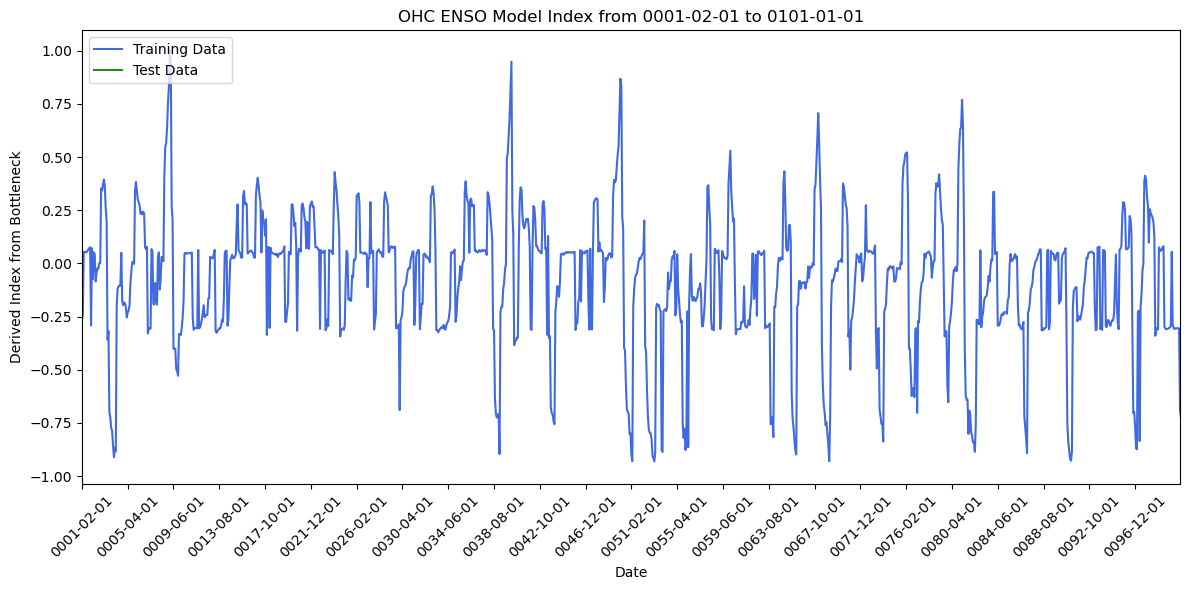

In [127]:
import matplotlib.pyplot as plt

# Select every 3rd point for the training data
train_data_sampled = ensomodel_train_index.iloc[::]
# Select every 3rd point for the test data
test_data_sampled = ensomodel_test_index.iloc[::]

# Plot the sampled training data
plt.figure(figsize=(12, 6))
plt.plot(train_data_sampled['date'], train_data_sampled[0], color='royalblue', label='Training Data')

# Plot the sampled test data
plt.plot(test_data_sampled['date'], test_data_sampled[0], color='forestgreen', label='Test Data')

# Customizing the plot
plt.xlabel('Date')
plt.ylabel('Derived Index from Bottleneck')
plt.title('OHC ENSO Model Index from 0001-02-01 to 0101-01-01')
selected_dates = list(train_data_sampled['date'][::50]) + list(test_data_sampled['date'][::50])
plt.xticks(selected_dates, rotation=45)
plt.legend(loc='upper left')
plt.xlim(['0001-02-01', '0101-01-01'])
plt.tight_layout()
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/figures/ohc_trainingslice_0825.png', dpi=350)
plt.show()